# Clean up Data suitable for DMD Analysis

> 2024-04-01 

Starting with a csv file of all data, create numpy files (`.npz`) which contains subsetted data and just the data needed for DMD analysis.

The csv files were created `2024-03-24` using matlab, though does not contain anything new should be easier to subset. 

## Loading the Full Data



In [ ]:
%config InlineBackend.figure_format='retina'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

unilateral_data = pd.read_csv("../../data/raw/2024-03-24-FullUnilateralMarkers.csv")
bilateral_data = pd.read_csv("../../data/raw/2024-03-24-FullBilateralMarkers.csv")

bilateral_data.columns

/var/folders/2m/t5bb62r50jbb_r1gf5dsdy680000gr/T/ipykernel_5504/1080570641.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Index(['frameID', 'seqID', 'time', 'HorzDistance', 'VertDistance',
       'body_pitch', 'BirdID', 'PerchDistance', 'Year', 'Naive', 'Obstacle',
       'IMU', 'left_wingtip_rot_xyz_1', 'left_wingtip_rot_xyz_2',
       'left_wingtip_rot_xyz_3', 'right_wingtip_rot_xyz_1',
       'right_wingtip_rot_xyz_2', 'right_wingtip_rot_xyz_3',
       'left_primary_rot_xyz_1', 'left_primary_rot_xyz_2',
       'left_primary_rot_xyz_3', 'right_primary_rot_xyz_1',
       'right_primary_rot_xyz_2', 'right_primary_rot_xyz_3',
       'left_secondary_rot_xyz_1', 'left_secondary_rot_xyz_2',
       'left_secondary_rot_xyz_3', 'right_secondary_rot_xyz_1',
       'right_secondary_rot_xyz_2', 'right_secondary_rot_xyz_3',
       'left_tailtip_rot_xyz_1', 'left_tailtip_rot_xyz_2',
       'left_tailtip_rot_xyz_3', 'right_tailtip_rot_xyz_1',
       'right_tailtip_rot_xyz_2', 'right_tailtip_rot_xyz_3'],
      dtype='object')

## Renaming the Columns

In [2]:
def replace_rot_xyz_name(data):
    """
    Replace the _rot_xyz_1 etc with _x, _y, _z in the column names
    """

    for col in data.columns:
        if col.endswith('_rot_xyz_1'):
            data.rename(columns={col: col.replace('_rot_xyz_1', '_x')}, inplace=True)
        elif col.endswith('_rot_xyz_2'):
            data.rename(columns={col: col.replace('_rot_xyz_2', '_y')}, inplace=True)
        elif col.endswith('_rot_xyz_3'):
            data.rename(columns={col: col.replace('_rot_xyz_3', '_z')}, inplace=True)
    return data

unilateral_data = replace_rot_xyz_name(unilateral_data)
unilateral_data.columns

bilateral_data = replace_rot_xyz_name(bilateral_data)
bilateral_data.columns

Index(['frameID', 'seqID', 'time', 'HorzDistance', 'VertDistance',
       'body_pitch', 'BirdID', 'PerchDistance', 'Year', 'Naive', 'Obstacle',
       'IMU', 'left_wingtip_x', 'left_wingtip_y', 'left_wingtip_z',
       'right_wingtip_x', 'right_wingtip_y', 'right_wingtip_z',
       'left_primary_x', 'left_primary_y', 'left_primary_z', 'right_primary_x',
       'right_primary_y', 'right_primary_z', 'left_secondary_x',
       'left_secondary_y', 'left_secondary_z', 'right_secondary_x',
       'right_secondary_y', 'right_secondary_z', 'left_tailtip_x',
       'left_tailtip_y', 'left_tailtip_z', 'right_tailtip_x',
       'right_tailtip_y', 'right_tailtip_z'],
      dtype='object')

## Splitting into Flight Behaviours

In the analysis we only want to look at certain flight behaviours at a time. For example, we will run DMD on just the first wingbeat, or the flapping behaviour, or gliding, or the landing section. 

We therefore need a column to indicate which behaviour each row belongs to.

In [ ]:
birdID_dict = {"drogon": 1, 
               "rhaegal" : 2, 
               "ruby" : 3, 
               "toothless" : 4, 
               "charmander" : 5}

perchDist_dict = {"5m" : 5, 
                  "7m" : 7, 
                  "9m" : 9, 
                  "12m": 12}



flight_behaviours = ["initial" 
                     "flapping"
                     "gliding"
                     "landing"]

# Using Time
initial_lims = {"drogon":     {"5m": 0.21, "7m": 0.20, "9m": 0.21, "12m": 0.22},
                "rhaegal":    {"5m": 0.21, "7m": 0.17, "9m": 0.22, "12m": 0.21},
                "ruby":       {"5m": 0.23, "7m": 0.22, "9m": 0.25, "12m": 0.26},
                "toothless":  {"5m": 0.21, "7m": 0.22, "9m": 0.22, "12m": 0.20},
                "charmander": {"9m": 0.3}}

# 2024-07-09 Subsetting a different section for the first flap
# Default to 0.4, if 2 decimal places then it has been looked into properly
twoflaps_lims = {"drogon":     {"5m": 0.4, "7m": 0.4, "9m": 0.4, "12m": 0.40},
                "rhaegal":     {"5m": 0.4, "7m": 0.4, "9m": 0.4, "12m": 0.40},
                "ruby":        {"5m": 0.4, "7m": 0.4, "9m": 0.4, "12m": 0.40},
                "toothless":   {"5m": 0.40, "7m": 0.42, "9m": 0.45, "12m": 0.40},
                "charmander":  {"9m": 0.4}}



flap_dict =     {"drogon":    {"5m": 0.55, "7m": 0.65, "9m": 0.75, "12m": 0.80},
                 "rhaegal":   {"5m": 0.55, "7m": 0.65, "9m": 0.80, "12m": 0.85},
                 "ruby":      {"5m": 0.60, "7m": 0.75, "9m": 0.87, "12m": 1.10},
                 "toothless": {"5m": 0.55, "7m": 0.70, "9m": 0.70, "12m": 0.85},
                 "charmander":{"9m": 0.9}}

# Distance from landing perch
landing_lims =  {"drogon":    {"5m": -1.3, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "rhaegal":   {"5m": -1.3, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "ruby":      {"5m": -1.0, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "toothless": {"5m": -1.3, "7m": -1.1, "9m": -1.1, "12m": -1.1},
                 "charmander":{"9m": -1.1}}


# Running on the bilatera data, both sides of the hawk per frame
bilateral_data["behaviour"] = ""

for birdID in birdID_dict:
    for perchID in perchDist_dict:

        index = bilateral_data['BirdID'] == birdID_dict[birdID]
        index = np.logical_and(index, bilateral_data['PerchDistance'] == perchDist_dict[perchID])

        if sum(index) == 0:
            continue

        initial  = np.logical_and(index,
                                  bilateral_data['time'] < initial_lims[birdID][perchID])
        bilateral_data.loc[initial, "behaviour"] = "flapping_initial"

        flapping = np.logical_and(index,
                                  (bilateral_data['time'] > 0) & 
                                  (bilateral_data['time'] < twoflaps_lims[birdID][perchID]) & 
                                  (bilateral_data['behaviour'] == ""))
        bilateral_data.loc[flapping,"behaviour"] = "flapping_second"

        flapping = np.logical_and(index,
                                  (bilateral_data['time'] > 0) & 
                                  (bilateral_data['time'] < flap_dict[birdID][perchID]) & 
                                  (bilateral_data['behaviour'] == ""))
        bilateral_data.loc[flapping,"behaviour"] = "flapping"

        gliding = np.logical_and(index,
                                (bilateral_data['time'] > flap_dict[birdID][perchID]) &
                                (-bilateral_data['HorzDistance'] < landing_lims[birdID][perchID]))
        bilateral_data.loc[gliding,"behaviour"] = "gliding"

        landing = np.logical_and(index,
                                (-bilateral_data['HorzDistance'] > landing_lims[birdID][perchID]))
        bilateral_data.loc[landing,"behaviour"] = "landing"


# Running on the bilatera data, both sides of the hawk per frame
unilateral_data["behaviour"] = ""

for birdID in birdID_dict:
    for perchID in perchDist_dict:

        index = unilateral_data['BirdID'] == birdID_dict[birdID]
        index = np.logical_and(index, unilateral_data['PerchDistance'] == perchDist_dict[perchID])

        if sum(index) == 0:
            continue

        initial  = np.logical_and(index,
                                  unilateral_data['time'] < initial_lims[birdID][perchID])
        unilateral_data.loc[initial, "behaviour"] = "flapping_initial"

        flapping = np.logical_and(index,
                                  (unilateral_data['time'] > 0) & 
                                  (unilateral_data['time'] < twoflaps_lims[birdID][perchID]) & 
                                  (unilateral_data['behaviour'] == ""))
        unilateral_data.loc[flapping,"behaviour"] = "flapping_second"


        flapping = np.logical_and(index,
                                  (unilateral_data['time'] > 0) & 
                                  (unilateral_data['time'] < flap_dict[birdID][perchID]) & 
                                  (unilateral_data['behaviour'] == ""))
        unilateral_data.loc[flapping,"behaviour"] = "flapping"

        gliding = np.logical_and(index,
                                (unilateral_data['time'] > flap_dict[birdID][perchID]) &
                                (-unilateral_data['HorzDistance'] < landing_lims[birdID][perchID]))
        unilateral_data.loc[gliding,"behaviour"] = "gliding"

        landing = np.logical_and(index,
                                (-unilateral_data['HorzDistance'] > landing_lims[birdID][perchID]))
        unilateral_data.loc[landing,"behaviour"] = "landing"



        
            
        
    


## Saving the pandas table

Rather than save as `.csv`, save as a `.pkl` file. This will allow us to easily load the data into python for analysis.


In [46]:
# Just save the initial_flapping data, and then all flapping data. 

subset = bilateral_data[bilateral_data['behaviour'].str.contains("flapping")]
subset.to_csv("../../data/processed/Flapping.csv")

subset = bilateral_data[bilateral_data['behaviour'].str.contains("flapping_initial")]
subset.to_csv("../../data/processed/Initial.csv")

subset = unilateral_data[unilateral_data['behaviour'].str.contains("flapping")]
subset.to_csv("../../data/processed/UnilateralFlapping.csv")

subset = unilateral_data[unilateral_data['behaviour'].str.contains("flapping_initial")]
subset.to_csv("../../data/processed/UnilateralInitial.csv")




## Saving as `.npz` files

Rather than saving the complete pandas table, transform to numpy arrays and save the data as `.npz` files.

We will save the data as `.npz` files which can be loaded into python using `np.load()`. This will allow us to easily load the data into python for analysis.



In [61]:
# For bilateral data, there is left and right markers. 

marker_column_names = bilateral_data.columns[bilateral_data.columns.str.contains("_")].tolist()


info_column_names = bilateral_data.columns[~bilateral_data.columns.str.contains("_")].tolist()
info_column_names.append(marker_column_names.pop(0)) # Remove body_pitch name


# Make the list into a numpy array
marker_column_names = np.array(marker_column_names)
info_column_names = np.array(info_column_names)

print(info_column_names)
print(marker_column_names)



# ------ Subset only the flapping data ------
subset_flapping = bilateral_data[bilateral_data['behaviour'].str.contains("flapping")]


# Get the data as numpy arrays
marker_data = subset_flapping[marker_column_names].to_numpy()
info_data = subset_flapping[info_column_names].to_numpy()

print(marker_data.shape)
print(info_data.shape)

# Save the data as npz
np.savez("../../data/samples/Flapping.npz", marker_data=marker_data, info_data=info_data)



# ------ Subset only the initial wingbeat data ------
subset_initial  = bilateral_data[bilateral_data['behaviour'].str.contains("initial")]

# Get the data as numpy arrays
marker_data = subset_initial[marker_column_names].to_numpy()
info_data = subset_initial[info_column_names].to_numpy()

print(marker_data.shape)
print(info_data.shape)

# Save the data as npz
np.savez("../../data/samples/Initial.npz", marker_data=marker_data, info_data=info_data)


# Save the column names
np.savez("../../data/samples/ColumnNames.npz", marker_column_names = marker_column_names, info_column_names = info_column_names)




['frameID' 'seqID' 'time' 'HorzDistance' 'VertDistance' 'BirdID'
 'PerchDistance' 'Year' 'Naive' 'Obstacle' 'IMU' 'behaviour' 'body_pitch']
['left_wingtip_x' 'left_wingtip_y' 'left_wingtip_z' 'right_wingtip_x'
 'right_wingtip_y' 'right_wingtip_z' 'left_primary_x' 'left_primary_y'
 'left_primary_z' 'right_primary_x' 'right_primary_y' 'right_primary_z'
 'left_secondary_x' 'left_secondary_y' 'left_secondary_z'
 'right_secondary_x' 'right_secondary_y' 'right_secondary_z'
 'left_tailtip_x' 'left_tailtip_y' 'left_tailtip_z' 'right_tailtip_x'
 'right_tailtip_y' 'right_tailtip_z']
(71095, 24)
(71095, 13)
(23578, 24)
(23578, 13)


In [62]:
# For unilateral data, there is just right markers. 

uni_marker_column_names = unilateral_data.columns[unilateral_data.columns.str.contains("_")].tolist()


uni_info_column_names = unilateral_data.columns[~unilateral_data.columns.str.contains("_")].tolist()
uni_info_column_names.append(uni_marker_column_names.pop(0)) # Remove body_pitch name


# Make the list into a numpy array
uni_marker_column_names = np.array(uni_marker_column_names)
uni_info_column_names = np.array(info_column_names)

print(info_column_names)
print(marker_column_names)



# ------ Subset only the flapping data ------
subset_flapping = unilateral_data[unilateral_data['behaviour'].str.contains("flapping")]


# Get the data as numpy arrays
marker_data = subset_flapping[uni_marker_column_names].to_numpy()
info_data = subset_flapping[uni_info_column_names].to_numpy()

print(marker_data.shape)
print(info_data.shape)

# Save the data as npz
np.savez("../../data/samples/UnilateralFlapping.npz", marker_data=marker_data, info_data=info_data)



# # ------ Subset only the initial wingbeat data ------
subset_initial  = unilateral_data[unilateral_data['behaviour'].str.contains("initial")]

# Get the data as numpy arrays
marker_data = subset_initial[uni_marker_column_names].to_numpy()
info_data = subset_initial[uni_info_column_names].to_numpy()

print(marker_data.shape)
print(info_data.shape)

# Save the data as npz
np.savez("../../data/samples/UnilateralInitial.npz", marker_data=marker_data, info_data=info_data)



# Save the column names
np.savez("../../data/samples/UnilateralColumnNames.npz", marker_column_names = uni_marker_column_names, info_column_names = uni_info_column_names)

['frameID' 'seqID' 'time' 'HorzDistance' 'VertDistance' 'BirdID'
 'PerchDistance' 'Year' 'Naive' 'Obstacle' 'IMU' 'behaviour' 'body_pitch']
['left_wingtip_x' 'left_wingtip_y' 'left_wingtip_z' 'right_wingtip_x'
 'right_wingtip_y' 'right_wingtip_z' 'left_primary_x' 'left_primary_y'
 'left_primary_z' 'right_primary_x' 'right_primary_y' 'right_primary_z'
 'left_secondary_x' 'left_secondary_y' 'left_secondary_z'
 'right_secondary_x' 'right_secondary_y' 'right_secondary_z'
 'left_tailtip_x' 'left_tailtip_y' 'left_tailtip_z' 'right_tailtip_x'
 'right_tailtip_y' 'right_tailtip_z']
(225685, 12)
(225685, 13)
(75469, 12)
(75469, 13)


In [55]:
print(marker_column_names)

['wingtip_x', 'wingtip_y', 'wingtip_z', 'primary_x', 'primary_y', 'primary_z', 'secondary_x', 'secondary_y', 'secondary_z', 'tailtip_x', 'tailtip_y', 'tailtip_z']


### Save subset numpy arrays 

In [64]:

birdNames = ["drogon", "rhaegal", "ruby", "toothless", "charmander"]
perchDist = ["9m", "12m"]

for bird in birdNames:
    for dist in perchDist:

# ------------BILATERAL INITIAL-----------------
        subset_bilateral = bilateral_data[(bilateral_data['BirdID'] == birdID_dict[bird]) & 
                                          (bilateral_data['PerchDistance'] == perchDist_dict[dist]) &
                                          (bilateral_data['behaviour'].str.contains("initial"))]
        
        if subset_bilateral.shape[0] == 0:
            continue
        savename = "../../data/samples/initial_" + bird + "_" + dist + ".npz"
        np.savez(savename, 
                 marker_data = subset_bilateral[marker_column_names].to_numpy(), 
                 info_data = subset_bilateral[info_column_names].to_numpy())
        
# ------------BILATERAL FLAPPING----------------
        subset_bilateral = bilateral_data[(bilateral_data['BirdID'] == birdID_dict[bird]) & 
                                          (bilateral_data['PerchDistance'] == perchDist_dict[dist]) &
                                          (bilateral_data['behaviour'].str.contains("flapping"))]
        
        if subset_bilateral.shape[0] == 0:
            continue
        savename = "../../data/samples/flapping_" + bird + "_" + dist + ".npz"
        np.savez(savename, 
                 marker_data = subset_bilateral[marker_column_names].to_numpy(), 
                 info_data = subset_bilateral[info_column_names].to_numpy())

# ------------UNILATERAL INITIAL-----------------        
        subset_unilateral = unilateral_data[(unilateral_data['BirdID'] == birdID_dict[bird]) & 
                                          (unilateral_data['PerchDistance'] == perchDist_dict[dist]) &
                                          (unilateral_data['behaviour'].str.contains("initial"))]
        if subset_unilateral.shape[0] == 0:
            continue
        savename = "../../data/samples/unilateral_data/initial_" + bird + "_" + dist + "_unilateral.npz"
        np.savez(savename, 
                 marker_data = subset_unilateral[uni_marker_column_names].to_numpy(), 
                 info_data = subset_unilateral[uni_info_column_names].to_numpy())

# --------------UNILATERAL FLAPPING---------------        
        subset_bilateral = unilateral_data[(unilateral_data['BirdID'] == birdID_dict[bird]) & 
                                          (unilateral_data['PerchDistance'] == perchDist_dict[dist]) &
                                          (unilateral_data['behaviour'].str.contains("flapping"))]
        
        if subset_bilateral.shape[0] == 0:
            continue
        savename = "../../data/samples/unilateral_data/flapping_" + bird + "_" + dist + "_unilateral.npz"
        np.savez(savename, 
                 marker_data = subset_bilateral[uni_marker_column_names].to_numpy(), 
                 info_data = subset_bilateral[uni_info_column_names].to_numpy())
        
        

        


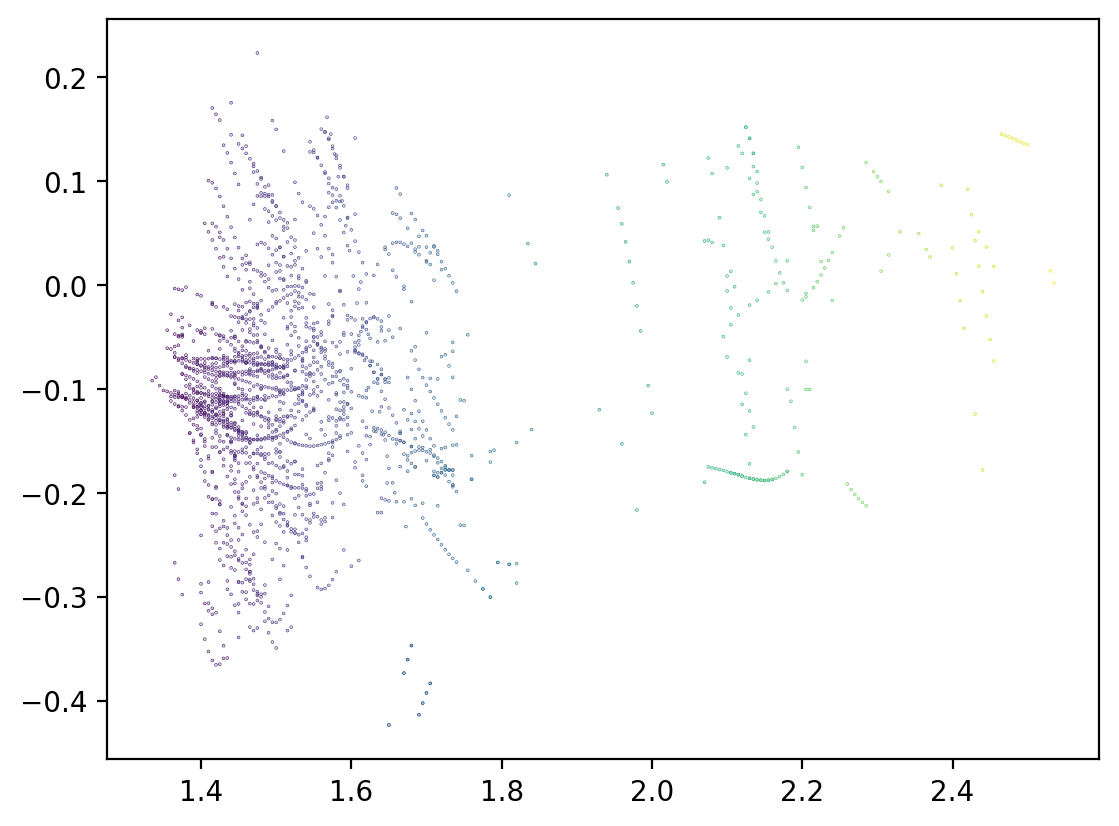

In [12]:
charmander = unilateral_data[(unilateral_data['BirdID'] == 5) & (unilateral_data["PerchDistance"]==9) & (unilateral_data['behaviour'].str.contains("landing"))]

# To check whether the string equals a phrase use ==. But to check whether the string contains a phrase use str.contains() but it is a series so to do that use .str.contains()

# Quick scatter plot of the data
plt.scatter(charmander['time'], charmander['wingtip_z'], s=0.05,c = charmander['time'])
# plt.scatter(charmander['time'], charmander['wingtip_z'], s=0.05,c = charmander['time'])



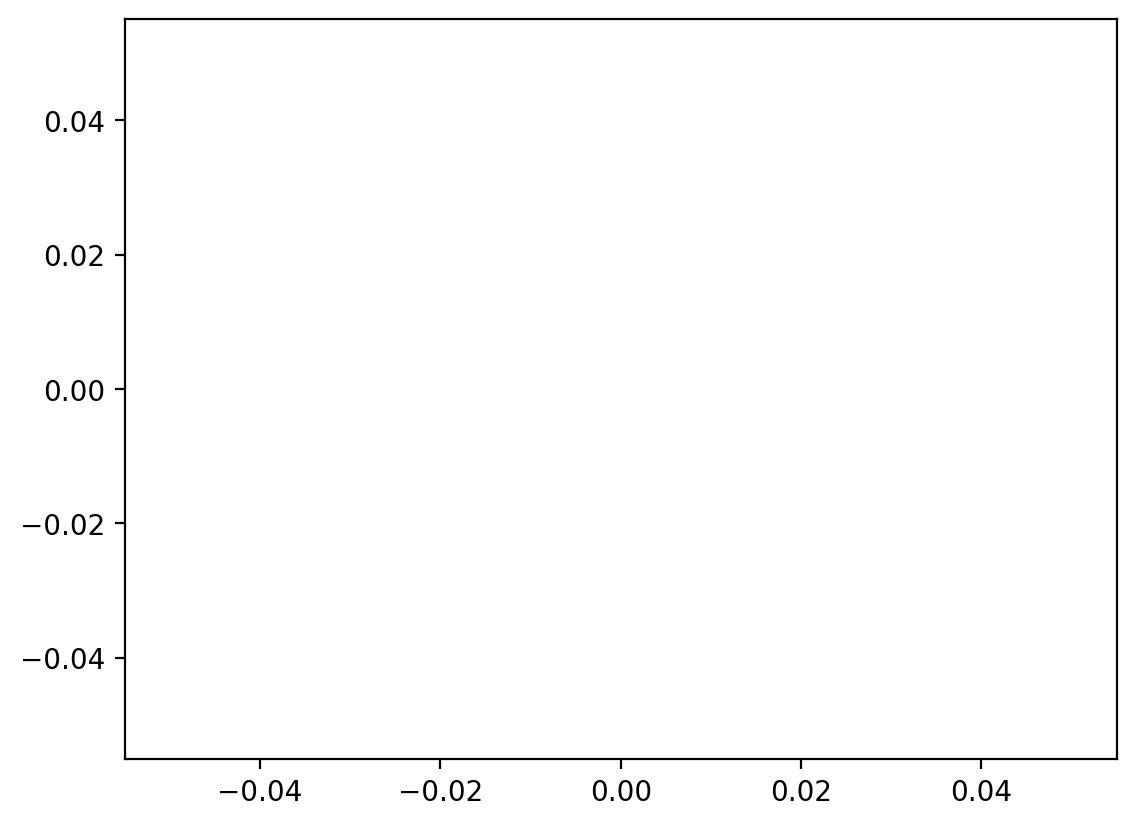

In [69]:

# np.load("../../data/samples/flapping_charmander_9m.npz")



# Quick scatter plot of the data
plt.scatter(-subset_bilateral['HorzDistance'], subset_bilateral['right_wingtip_z'], s=0.05,c = subset_bilateral['time'])
plt.scatter(-subset_bilateral['HorzDistance'], subset_bilateral['left_wingtip_z'], s=0.05,c = subset_bilateral['time'])

